# Training Process Analysis — SpeakingDetectorRNN

Analyzes the completed `scripts/train.py` run (see `logs/train_metrics.csv` / `logs/train.log`)
and the held-out test-split evaluation (`scripts/evaluate.py` → `evaluation/`): training/validation
loss & accuracy curves, the generalization gap (overfitting check), and the full classification
metric suite — accuracy, precision, recall, F1, ROC/PR curves, confusion matrix — on the test split
the model never saw during training or early stopping.

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / "src"))
sys.path.append(str(PROJECT_ROOT / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from config import (
    LOGS_DIR, TRAIN_METRICS_FILENAME, CHECKPOINTS_DIR, BEST_CHECKPOINT_FILENAME,
    EARLY_STOPPING_PATIENCE,
)
from metrics import (
    compute_metrics, format_report, plot_confusion_matrix, plot_roc_curve, plot_pr_curve,
    plot_loss_curve, plot_accuracy_curve, COLOR_BLUE, COLOR_GREEN, COLOR_MUTED, COLOR_GRID,
)
from dataset import get_dataloader
from model import SpeakingDetectorRNN
from evaluate import collect_predictions

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

def style_axes(ax):
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(COLOR_MUTED)
    ax.tick_params(colors=COLOR_MUTED)
    ax.grid(color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

## 2. Training curves (train vs val)

In [2]:
metrics_df = pd.read_csv(LOGS_DIR / TRAIN_METRICS_FILENAME)

best_epoch = int(metrics_df.loc[metrics_df["val_loss"].idxmin(), "epoch"])
best_val_loss = metrics_df["val_loss"].min()
last_epoch = int(metrics_df["epoch"].max())

print(f"trained {last_epoch} epochs, stopped early "
      f"({EARLY_STOPPING_PATIENCE} epochs without val_loss improvement after the best one)")
print(f"best epoch: {best_epoch}  (val_loss={best_val_loss:.4f}) -- this is the checkpoint saved as best_model.pt")
metrics_df

trained 27 epochs, stopped early (10 epochs without val_loss improvement after the best one)
best epoch: 17  (val_loss=0.4131) -- this is the checkpoint saved as best_model.pt


,epoch,train_loss,train_acc,val_loss,val_acc,seconds
0,1,0.613315,0.658299,0.547788,0.699949,37.8
1,2,0.573306,0.691271,0.543477,0.695492,38.3
2,3,0.560922,0.706631,0.564723,0.680166,38.0
3,4,0.541895,0.724027,0.597270,0.659406,38.3
4,5,0.522974,0.740721,0.483279,0.773960,37.5
5,6,0.454614,0.790887,0.462550,0.778272,37.9
6,7,0.434862,0.800376,0.428183,0.803213,38.4
7,8,0.422141,0.806110,0.423787,0.807155,38.4
8,9,0.416246,0.809739,0.438826,0.796929,38.1
9,10,0.411476,0.812190,0.423588,0.809075,38.5


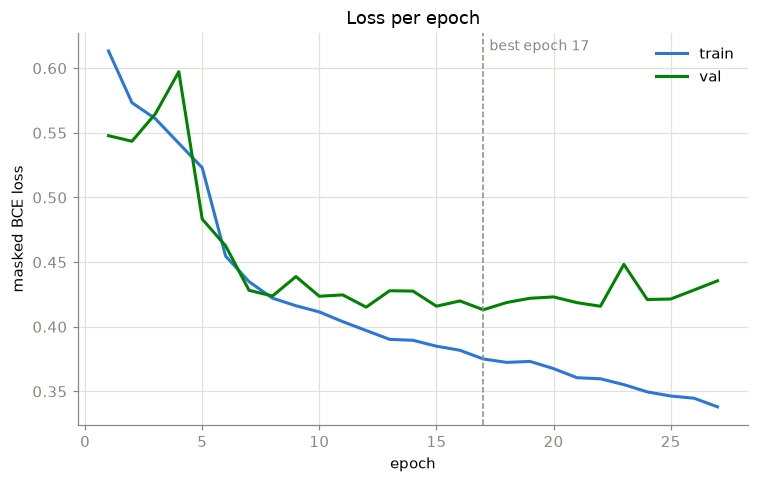

In [3]:
plot_loss_curve(metrics_df, best_epoch=best_epoch);

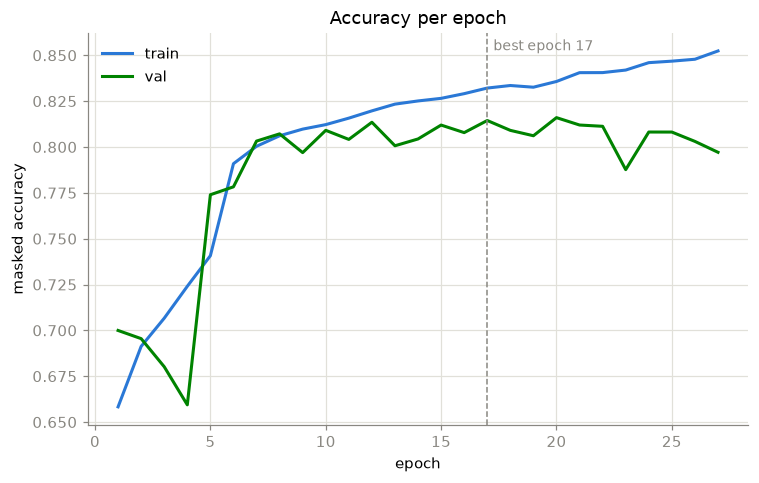

In [4]:
plot_accuracy_curve(metrics_df, best_epoch=best_epoch);

### Generalization gap (train_acc − val_acc)

A widening gap over epochs is the overfitting signal early stopping is watching for indirectly
(via val_loss) — this makes it explicit.

gap at best epoch (17): +0.0177
gap at final epoch (27): +0.0553


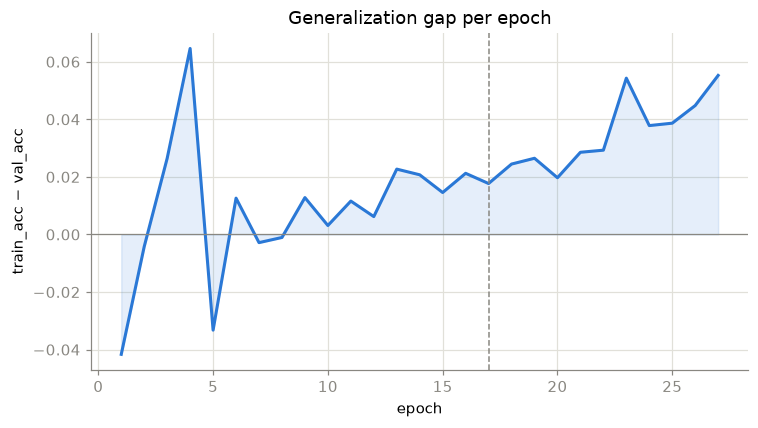

In [5]:
gap = metrics_df["train_acc"] - metrics_df["val_acc"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(metrics_df["epoch"], gap, color=COLOR_BLUE, linewidth=2)
ax.fill_between(metrics_df["epoch"], 0, gap, color=COLOR_BLUE, alpha=0.12)
ax.axvline(best_epoch, color=COLOR_MUTED, linewidth=1, linestyle="--")
ax.axhline(0, color=COLOR_MUTED, linewidth=0.8)
ax.set_xlabel("epoch")
ax.set_ylabel("train_acc − val_acc")
ax.set_title("Generalization gap per epoch")
style_axes(ax)
fig.tight_layout()

print(f"gap at best epoch ({best_epoch}): {gap[metrics_df['epoch'] == best_epoch].iloc[0]:+.4f}")
print(f"gap at final epoch ({last_epoch}): {gap.iloc[-1]:+.4f}")

## 3. Held-out test-set evaluation

Loads `checkpoints/best_model.pt` (the lowest-val-loss checkpoint from the run above) and runs it
on the **test** split — the 30% of `data/processed/val/` held out by `scripts/split_val_test.py`
and never touched during training or early stopping (see `scripts/evaluate.py`, which this reuses
directly). Only real, detected frames (`mask == 1`) are scored, matching the training/val loss and
accuracy convention.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SpeakingDetectorRNN().to(device)
model.load_state_dict(torch.load(CHECKPOINTS_DIR / BEST_CHECKPOINT_FILENAME, map_location=device))

test_loader = get_dataloader("test", shuffle=False)
y_true, y_pred, y_prob = collect_predictions(model, test_loader, device)

test_metrics = compute_metrics(y_true, y_pred, y_prob)
print(format_report(test_metrics))

[test] LandmarkSequenceDataset: 1826 tracks kept, 1745 rejected (< 50% detected frames), out of 3571 total


n_samples=160668
accuracy=0.8434
precision=0.7198  recall=0.5273  f1=0.6087
roc_auc=0.8845  pr_auc=0.7204
confusion matrix (rows=true, cols=pred):
                    pred_NOT_SPEAKING     pred_SPEAKING_AUDIBLE
  true_NOT_SPEAKING       115933                 7620
  true_SPEAKING_AUDIBLE      17543                19572


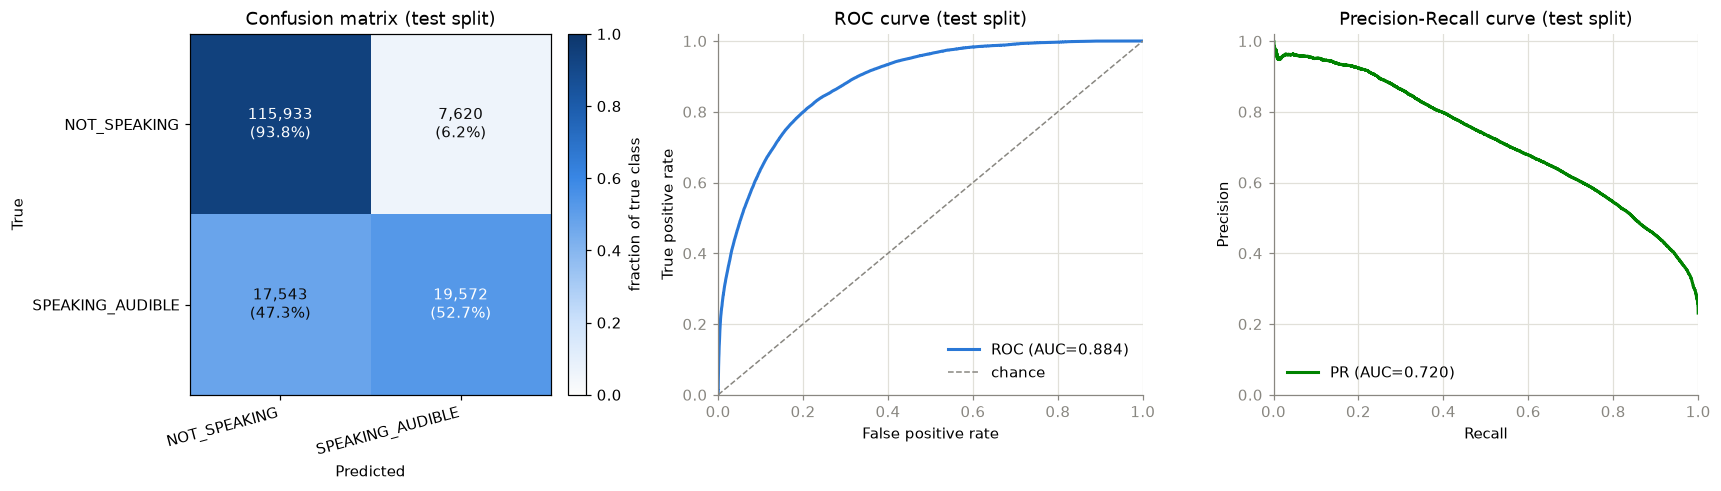

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_confusion_matrix(test_metrics, ax=axes[0])
plot_roc_curve(test_metrics, ax=axes[1])
plot_pr_curve(test_metrics, ax=axes[2])
fig.tight_layout()

## 4. Summary

In [8]:
from IPython.display import Markdown, display

gap_at_best = gap[metrics_df["epoch"] == best_epoch].iloc[0]
gap_at_last = gap.iloc[-1]

display(Markdown(f"""
- Training ran **{last_epoch} epochs** before early stopping (patience={EARLY_STOPPING_PATIENCE}),
  best checkpoint at **epoch {best_epoch}** with val_loss={best_val_loss:.4f}.
- Train/val gap: {gap_at_best:+.4f} at the best epoch, {gap_at_last:+.4f} at the final epoch —
  {"widening" if gap_at_last > gap_at_best else "not widening"} toward the end of training.
- On the held-out **test** split: accuracy={test_metrics['accuracy']:.3f},
  precision={test_metrics['precision']:.3f}, recall={test_metrics['recall']:.3f},
  f1={test_metrics['f1']:.3f}, ROC-AUC={test_metrics['roc_auc']:.3f}, PR-AUC={test_metrics['pr_auc']:.3f}.
- Recall trails precision for SPEAKING_AUDIBLE at the default 0.5 threshold (see the confusion
  matrix above) despite a strong ROC-AUC — the model ranks the classes well but the default
  threshold is conservative toward SPEAKING_AUDIBLE. Worth exploring a lower decision threshold
  (see the PR curve above) if recall on speaking frames matters more than precision downstream.
"""))


- Training ran **27 epochs** before early stopping (patience=10),
  best checkpoint at **epoch 17** with val_loss=0.4131.
- Train/val gap: +0.0177 at the best epoch, +0.0553 at the final epoch —
  widening toward the end of training.
- On the held-out **test** split: accuracy=0.843,
  precision=0.720, recall=0.527,
  f1=0.609, ROC-AUC=0.884, PR-AUC=0.720.
- Recall trails precision for SPEAKING_AUDIBLE at the default 0.5 threshold (see the confusion
  matrix above) despite a strong ROC-AUC — the model ranks the classes well but the default
  threshold is conservative toward SPEAKING_AUDIBLE. Worth exploring a lower decision threshold
  (see the PR curve above) if recall on speaking frames matters more than precision downstream.
